Loading data

In [6]:
import pandas as pd
import numpy as np
import glob
folder_path = (r"D:\data")
files = glob.glob(folder_path + "/*.csv")
print(files)




['D:\\data\\01_fund_master.csv', 'D:\\data\\02_nav_history.csv', 'D:\\data\\03_aum_by_fund_house.csv', 'D:\\data\\04_monthly_sip_inflows.csv', 'D:\\data\\05_category_inflows.csv', 'D:\\data\\06_industry_folio_count.csv', 'D:\\data\\07_scheme_performance.csv', 'D:\\data\\08_investor_transactions.csv', 'D:\\data\\09_portfolio_holdings.csv', 'D:\\data\\10_benchmark_indices.csv']


In [7]:
df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)
print(df.head())

   amfi_code       fund_house                                   scheme_name  \
0   119551.0  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1   119552.0  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2   119598.0  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3   119599.0  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4   119120.0  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  ...  kyc_status  stock_symbol stock_n

Compute Daily Returns

In [8]:
df ['daily_return'] = df.groupby('scheme_name')['nav'].pct_change()

Validate Return Distribution

In [11]:
dist_stats=df.groupby('scheme_name')['daily_return'].agg(['mean', 'median', 'std', 'min', 'max'])
print(dist_stats.head())

                                               mean  median  std  min  max
scheme_name                                                               
ABSL Frontline Equity Fund - Regular - Growth   NaN     NaN  NaN  NaN  NaN
ABSL Liquid Fund - Regular - Growth             NaN     NaN  NaN  NaN  NaN
ABSL Small Cap Fund - Regular - Growth          NaN     NaN  NaN  NaN  NaN
Axis Bluechip Fund - Direct - Growth            NaN     NaN  NaN  NaN  NaN
Axis Bluechip Fund - Regular - Growth           NaN     NaN  NaN  NaN  NaN


In [17]:
import plotly_express as px
sample_fund=df['scheme_name'].unique()[0]
fig = px.histogram(df, x='daily_return', nbins=50, title=f'{sample_fund} Return Distridution')
fig.show()

CAGR Calculation

In [9]:
def calculate_cagr(group, years):

    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = group[group['date']>=start_date]

    if len(temp)<2:
        return np.nan

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    return (end_nav/start_nav)**(1/years)-1

comparison table

In [11]:
import pandas as pd
df['date']=pd.to_datetime(df['date'], errors='coerce')
df['nav']=pd.to_numeric(df['nav'], errors='coerce')
print(df['date'].dtype)
print(df['nav'].dtype)

datetime64[us]
float64


In [12]:
funds = []

for name,g in df.groupby('scheme_name'):

    funds.append({
        "Fund":name,
        "CAGR_1Y":calculate_cagr(g,1),
        "CAGR_3Y":calculate_cagr(g,3),
        "CAGR_5Y":calculate_cagr(g,5)
    })

cagr_table = pd.DataFrame(funds)

cagr_table.head()

,Fund,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
1,ABSL Liquid Fund - Regular - Growth,NaN,NaN,NaN
2,ABSL Small Cap Fund - Regular - Growth,NaN,NaN,NaN
3,Axis Bluechip Fund - Direct - Growth,NaN,NaN,NaN
4,Axis Bluechip Fund - Regular - Growth,NaN,NaN,NaN


Sharpe Ratio

Risk-free rate

In [13]:
Rf = 0.065

Annualized daily RF

In [14]:
rf_daily = Rf/252

In [15]:
def sharpe(group):

    r = group['daily_return'].dropna()

    excess = r-rf_daily

    return (excess.mean()/r.std())*np.sqrt(252)

In [16]:
sharpe_scores = (
    df.groupby("scheme_name")
      .apply(sharpe)
      .reset_index(name="Sharpe")
)

sharpe_scores = sharpe_scores.sort_values("Sharpe",ascending=False)

sharpe_scores.head()

,scheme_name,Sharpe
0,ABSL Frontline Equity Fund - Regular - Growth,NaN
1,ABSL Liquid Fund - Regular - Growth,NaN
2,ABSL Small Cap Fund - Regular - Growth,NaN
3,Axis Bluechip Fund - Direct - Growth,NaN
4,Axis Bluechip Fund - Regular - Growth,NaN


Sortino Ratio

In [17]:
def sortino(group):

    r = group['daily_return'].dropna()

    downside = r[r<0]

    downside_std = downside.std()

    rf_daily = 0.065/252

    return ((r.mean()-rf_daily)/downside_std)*np.sqrt(252)

In [18]:
sortino_scores = (
    df.groupby("scheme_name")
      .apply(sortino)
      .reset_index(name="Sortino")
)

Alpha & Beta

Create benchmark returns

In [21]:
benchmark = (
    df[df['index_name']=="Nifty 100"]
    [['date','close_value']]
    .drop_duplicates()
)

benchmark = benchmark.sort_values('date')

benchmark['benchmark_return'] = benchmark['close_value'].pct_change()

merge

In [22]:
merged = df.merge(
    benchmark[['date','benchmark_return']],
    on='date',
    how='left'
)

Regression

In [23]:
alpha_beta=[]

for fund,g in merged.groupby('scheme_name'):

    temp = g[['daily_return','benchmark_return']].dropna()

    if len(temp)<30:
        continue

    result = linregress(
        temp['benchmark_return'],
        temp['daily_return']
    )

    alpha = result.intercept*252
    beta = result.slope

    alpha_beta.append({
        "Fund":fund,
        "Alpha":alpha,
        "Beta":beta
    })

alpha_beta = pd.DataFrame(alpha_beta)

save

In [24]:
alpha_beta.to_csv("alpha_beta.csv",index=False)

Maximum Drawdown

In [25]:
def max_drawdown(group):

    nav = group['nav']

    running_max = nav.cummax()

    dd = nav/running_max -1

    return dd.min()

In [26]:
drawdown = (
    df.groupby("scheme_name")
      .apply(max_drawdown)
      .reset_index(name="Max_Drawdown")
)

Worst drawdown period

In [28]:
print(df['nav'].dtype)
print(df['nav'].isna().sum())
print(df['nav'].head())

float64
41533
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: nav, dtype: float64


In [29]:
df = df.dropna(subset=['nav'])

In [31]:
def max_drawdown(group):
    nav = group['nav'].dropna()

    if len(nav) < 2:
        return np.nan

    running_max = nav.cummax()
    drawdown = nav / running_max - 1

    return drawdown.min()

In [34]:
def drawdown_period(group):
    group = group.sort_values('date')
    nav = group['nav'].dropna()

    if len(nav) < 2:
        return pd.Series({
            'Start': pd.NaT,
            'End': pd.NaT,
            'MaxDD': np.nan
        })

    running_max = nav.cummax()
    dd = nav / running_max - 1

    end_idx = dd.idxmin()

    if pd.isna(end_idx):
        return pd.Series({
            'Start': pd.NaT,
            'End': pd.NaT,
            'MaxDD': np.nan
        })

    start_idx = nav.loc[:end_idx].idxmax()

    return pd.Series({
        'Start': group.loc[start_idx, 'date'],
        'End': group.loc[end_idx, 'date'],
        'MaxDD': dd.min()
    })

In [37]:
print("Missing NAV:", df['nav'].isna().sum())
print("Total rows:", len(df))
print("Unique funds:", df['scheme_name'].nunique())

print(df.groupby('scheme_name')['nav'].count().head())

Missing NAV: 0
Total rows: 46000
Unique funds: 0
Series([], Name: nav, dtype: int64)


In [38]:
df[['scheme_name', 'date', 'nav']].head(10)

print(df['nav'].dtype)
print(df['nav'].isna().sum())
print(df.groupby('scheme_name')['nav'].count().describe())

float64
0
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: nav, dtype: float64


Fund Scorecard

In [40]:

print(cagr_table.columns)
print(sharpe_scores.columns)
print(alpha_beta.columns)
print(drawdown.columns)

Index(['Fund', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y'], dtype='str')
Index(['scheme_name', 'Sharpe'], dtype='str')
RangeIndex(start=0, stop=0, step=1)
Index(['scheme_name', 'Max_Drawdown'], dtype='str')


In [46]:
# CAGR table
score = cagr_table.copy()

# Sharpe
score = score.merge(
    sharpe_scores,
    left_on='Fund',
    right_on='scheme_name',
    how='left'
).drop(columns='scheme_name')

# Alpha (from dataset)
alpha_df = (
    df.groupby('scheme_name')['alpha']
      .first()
      .reset_index()
)

alpha_df.columns = ['Fund', 'Alpha']

score = score.merge(alpha_df, on='Fund', how='left')

# Expense Ratio
expense_df = (
    df.groupby('scheme_name')['expense_ratio_pct']
      .first()
      .reset_index()
)

expense_df.columns = ['Fund', 'expense_ratio_pct']

score = score.merge(expense_df, on='Fund', how='left')

# Maximum Drawdown (from previous step)
drawdown.columns = ['scheme_name', 'Max_Drawdown']

score = score.merge(
    drawdown,
    left_on='Fund',
    right_on='scheme_name',
    how='left'
).drop(columns='scheme_name')

In [48]:
score['ReturnRank'] = score['CAGR_3Y'].rank(ascending=False)

score['SharpeRank'] = score['Sharpe'].rank(ascending=False)

score['AlphaRank'] = score['Alpha'].rank(ascending=False)

score['ExpenseRank'] = score['expense_ratio_pct'].rank(ascending=True)

score['DDRank'] = score['Max_Drawdown'].rank(ascending=False)

In [49]:
score['RawScore'] = (
    30 * score['ReturnRank'] +
    25 * score['SharpeRank'] +
    20 * score['AlphaRank'] +
    15 * score['ExpenseRank'] +
    10 * score['DDRank']
)

score['FundScore'] = (
    (score['RawScore'] - score['RawScore'].min()) /
    (score['RawScore'].max() - score['RawScore'].min())
) * 100

score = score.sort_values('FundScore', ascending=False)

score.to_csv('fund_scorecard.csv', index=False)

print(score.head())

                                            Fund  CAGR_1Y  CAGR_3Y  CAGR_5Y  \
0  ABSL Frontline Equity Fund - Regular - Growth      NaN      NaN      NaN   
1            ABSL Liquid Fund - Regular - Growth      NaN      NaN      NaN   
2         ABSL Small Cap Fund - Regular - Growth      NaN      NaN      NaN   
3           Axis Bluechip Fund - Direct - Growth      NaN      NaN      NaN   
4          Axis Bluechip Fund - Regular - Growth      NaN      NaN      NaN   

   Sharpe  Alpha  expense_ratio_pct  Max_Drawdown  ReturnRank  SharpeRank  \
0     NaN    NaN                NaN           NaN         NaN         NaN   
1     NaN    NaN                NaN           NaN         NaN         NaN   
2     NaN    NaN                NaN           NaN         NaN         NaN   
3     NaN    NaN                NaN           NaN         NaN         NaN   
4     NaN    NaN                NaN           NaN         NaN         NaN   

   AlphaRank  ExpenseRank  DDRank  RawScore  FundScore  
0    

In [51]:
score.to_csv("fund_scorecard.csv",index=False)

In [50]:
print(cagr_table.columns.tolist())
print(sharpe_scores.columns.tolist())
print(drawdown.columns.tolist())

['Fund', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']
['scheme_name', 'Sharpe']
['scheme_name', 'Max_Drawdown']


Top 5 Funds

In [52]:
top5 = score.sort_values(
    'FundScore',
    ascending=False
).head(5)

top5

,Fund,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,expense_ratio_pct,Max_Drawdown,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DDRank,RawScore,FundScore
0,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABSL Liquid Fund - Regular - Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABSL Small Cap Fund - Regular - Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Axis Bluechip Fund - Direct - Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Axis Bluechip Fund - Regular - Growth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Benchmark Comparison Chart

C:\Users\sktec\AppData\Local\Temp\ipykernel_12832\2278289821.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


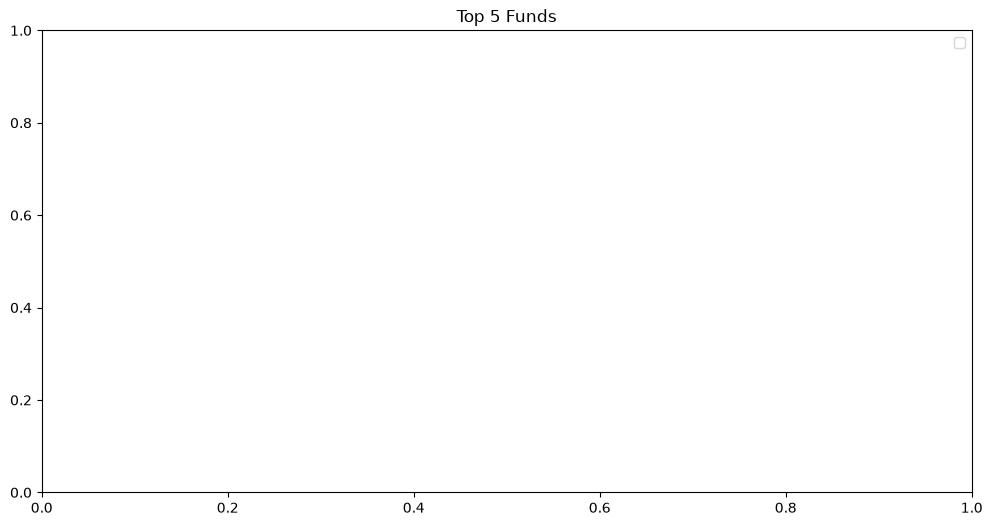

In [56]:
plt.figure(figsize=(12,6))

for fund in top5['Fund']:

    temp = df[df['scheme_name'] == fund].sort_values('date')

    if temp.empty:
        continue

    plt.plot(
        temp['date'],
        temp['nav'] / temp['nav'].iloc[0],
        label=fund
    )

plt.legend()
plt.title("Top 5 Funds")
plt.show()

Tracking Error

In [58]:
tracking=[]

for fund,g in merged.groupby('scheme_name'):

    temp = g[['daily_return','benchmark_return']].dropna()

    if len(temp)<30:
        continue

    te = np.std(
        temp['daily_return']-
        temp['benchmark_return']
    )*np.sqrt(252)

    tracking.append({
        "Fund":fund,
        "TrackingError":te
    })

tracking = pd.DataFrame(tracking)